In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
Dataset = pd.read_csv('../Data/eagle_subset.csv',index_col = 'OBJECTID')
Dataset.drop(['risk_name'],axis=1,inplace=True)
Dataset.head()


,Season_longshort,DEM_IA,TPI_IA,Slope_IA,d2water_IA,d2edge_IA,d2Landfills_IA,d2Feedlots_IA,d2streets,d2nestsV2_IA,northness,month_factor,risk_class,validation_set
OBJECTID,,,,,,,,,,,,,,
2725509,Dispersal/migration,229.74,0.010000,0.05,0.00,237.40,11203.84,3835.18,226.68,753.29,0.985585,Jun,0,Train
1403793,Fledgling period,280.34,-0.220000,0.55,6.91,7.30,13331.30,1966.93,394.48,583.21,-0.958698,Aug,2,Test
556960,Dispersal/migration,330.52,4.430000,5.91,1250.93,0.00,15543.21,3456.01,509.18,2139.79,-0.999999,Aug,0,Train
1120710,Local movements,186.57,0.009989,0.29,291.36,22.13,17156.93,5284.26,504.37,1936.59,-0.278651,Mar,2,Train
1135477,Local movements,208.59,1.020000,4.40,54.43,4.85,5455.17,3655.67,516.63,10526.36,0.238476,Jan,2,Train


In [5]:
X_train_full = Dataset[Dataset['validation_set'] == 'Train']
y_train = X_train_full[['risk_class']]
X_train = X_train_full.drop(['risk_class','validation_set'], axis=1)

X_test_full = Dataset[Dataset['validation_set'] == 'Test']
y_test = X_test_full[['risk_class']]
X_test = X_test_full.drop(['risk_class','validation_set'], axis=1)


In [13]:
Dataset.head()

,Season_longshort,DEM_IA,TPI_IA,Slope_IA,d2water_IA,d2edge_IA,d2Landfills_IA,d2Feedlots_IA,d2streets,d2nestsV2_IA,northness,month_factor,risk_class,validation_set
OBJECTID,,,,,,,,,,,,,,
2725509,Dispersal/migration,229.74,0.010000,0.05,0.00,237.40,11203.84,3835.18,226.68,753.29,0.985585,Jun,0,Train
1403793,Fledgling period,280.34,-0.220000,0.55,6.91,7.30,13331.30,1966.93,394.48,583.21,-0.958698,Aug,2,Test
556960,Dispersal/migration,330.52,4.430000,5.91,1250.93,0.00,15543.21,3456.01,509.18,2139.79,-0.999999,Aug,0,Train
1120710,Local movements,186.57,0.009989,0.29,291.36,22.13,17156.93,5284.26,504.37,1936.59,-0.278651,Mar,2,Train
1135477,Local movements,208.59,1.020000,4.40,54.43,4.85,5455.17,3655.67,516.63,10526.36,0.238476,Jan,2,Train


In [12]:
Dataset.columns

Index(['Season_longshort', 'DEM_IA', 'TPI_IA', 'Slope_IA', 'd2water_IA',
       'd2edge_IA', 'd2Landfills_IA', 'd2Feedlots_IA', 'd2streets',
       'd2nestsV2_IA', 'northness', 'month_factor', 'risk_class',
       'validation_set'],
      dtype='object')

In [ ]:
# 'Season_longshort', month_factor

In [18]:
np.corrcoef(Dataset['col'], Dataset['risk_class'])

'Season_longshort'

In [21]:
for col in Dataset.columns:
    try:
      print(col, 'correlation coefficient: ', np.corrcoef(Dataset[col], Dataset['risk_class'])[0][1] )
    except:
        print(col)
        

Season_longshort
DEM_IA correlation coefficient:  -0.15054008376286254
TPI_IA correlation coefficient:  -0.029537397987230336
Slope_IA correlation coefficient:  0.07753757087643035
d2water_IA correlation coefficient:  -0.18127087455455954
d2edge_IA correlation coefficient:  -0.18651165674592596
d2Landfills_IA correlation coefficient:  0.007912062022355473
d2Feedlots_IA correlation coefficient:  0.08324877409038298
d2streets correlation coefficient:  0.09377299911770517
d2nestsV2_IA correlation coefficient:  -0.136062173533929
northness correlation coefficient:  0.0046894028989590605
month_factor
risk_class correlation coefficient:  1.0
validation_set


In [31]:
SLF, other = pd.factorize(Dataset['Season_longshort'])
SLF

array([0, 1, 0, ..., 2, 0, 2], shape=(10000,))

In [32]:
Dataset['Season_longshort'] = SLF

In [36]:
MFF, other = pd.factorize(Dataset['month_factor'])
MFF

array([0, 1, 1, ..., 4, 2, 2], shape=(10000,))

In [37]:
Dataset['month_factor'] = MFF

In [38]:
Dataset.head()

,Season_longshort,DEM_IA,TPI_IA,Slope_IA,d2water_IA,d2edge_IA,d2Landfills_IA,d2Feedlots_IA,d2streets,d2nestsV2_IA,northness,month_factor,risk_class,validation_set
OBJECTID,,,,,,,,,,,,,,
2725509,0,229.74,0.010000,0.05,0.00,237.40,11203.84,3835.18,226.68,753.29,0.985585,0,0,Train
1403793,1,280.34,-0.220000,0.55,6.91,7.30,13331.30,1966.93,394.48,583.21,-0.958698,1,2,Test
556960,0,330.52,4.430000,5.91,1250.93,0.00,15543.21,3456.01,509.18,2139.79,-0.999999,1,0,Train
1120710,2,186.57,0.009989,0.29,291.36,22.13,17156.93,5284.26,504.37,1936.59,-0.278651,2,2,Train
1135477,2,208.59,1.020000,4.40,54.43,4.85,5455.17,3655.67,516.63,10526.36,0.238476,3,2,Train


In [39]:
for col in Dataset.columns:
    try:
      print(col, 'correlation coefficient: ', np.corrcoef(Dataset[col], Dataset['risk_class'])[0][1] )
    except:
        print(col)
        

Season_longshort correlation coefficient:  0.09015203258426861
DEM_IA correlation coefficient:  -0.15054008376286254
TPI_IA correlation coefficient:  -0.029537397987230336
Slope_IA correlation coefficient:  0.07753757087643035
d2water_IA correlation coefficient:  -0.18127087455455954
d2edge_IA correlation coefficient:  -0.18651165674592596
d2Landfills_IA correlation coefficient:  0.007912062022355473
d2Feedlots_IA correlation coefficient:  0.08324877409038298
d2streets correlation coefficient:  0.09377299911770517
d2nestsV2_IA correlation coefficient:  -0.136062173533929
northness correlation coefficient:  0.0046894028989590605
month_factor correlation coefficient:  0.07917364176029519
risk_class correlation coefficient:  1.0
validation_set


In [6]:
X_train.head()

,Season_longshort,DEM_IA,TPI_IA,Slope_IA,d2water_IA,d2edge_IA,d2Landfills_IA,d2Feedlots_IA,d2streets,d2nestsV2_IA,northness,month_factor
OBJECTID,,,,,,,,,,,,
2725509,Dispersal/migration,229.74,0.010000,0.05,0.00,237.40,11203.84,3835.18,226.68,753.29,0.985585,Jun
556960,Dispersal/migration,330.52,4.430000,5.91,1250.93,0.00,15543.21,3456.01,509.18,2139.79,-0.999999,Aug
1120710,Local movements,186.57,0.009989,0.29,291.36,22.13,17156.93,5284.26,504.37,1936.59,-0.278651,Mar
1135477,Local movements,208.59,1.020000,4.40,54.43,4.85,5455.17,3655.67,516.63,10526.36,0.238476,Jan
1514768,Dispersal/migration,228.23,0.120000,0.46,25.16,876.81,17963.27,5795.95,1148.37,6436.98,0.169967,Sep


In [7]:
features_cat = [cname for cname in X_train.columns if  
                    X_train[cname].dtype == "object"]         # one hot encoding for categorical
 
features_num = [cname for cname in X_train.columns if 
                  X_train[cname].dtype in ['int64', 'float64']]   #standardscaler maybe later?


#no imputer because no blank data? i reckon

In [8]:
transformers_cat = Pipeline(steps=[
    ('onehot',OneHotEncoder(handle_unknown='ignore')),
])
transformers_num = StandardScaler()


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', transformers_cat, features_cat),
        ('num',transformers_num,features_num)
    ])


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay as CMD


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,preds)
print(cm)
print("accuracy score: ",accuracy_score(y_test,preds))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


KNN
Accuracy: 0.5988
F1 Score (macro): 0.4195


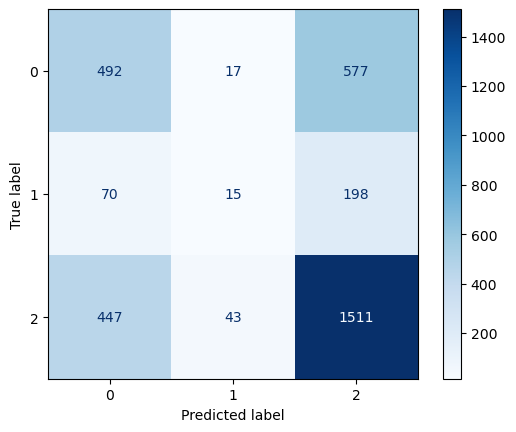


Random Forest
Accuracy: 0.6487
F1 Score (macro): 0.4291


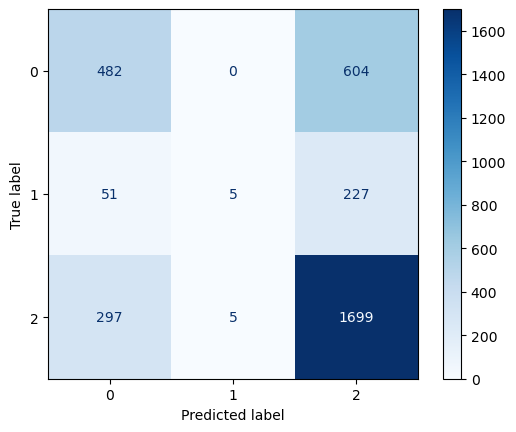


Gradient Boosting
Accuracy: 0.6493
F1 Score (macro): 0.4218


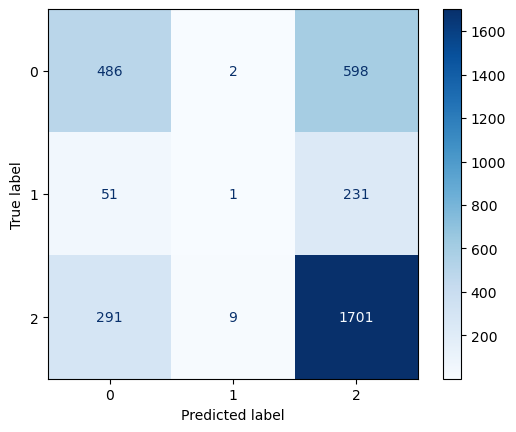


Logistic Regression
Accuracy: 0.6243
F1 Score (macro): 0.3763


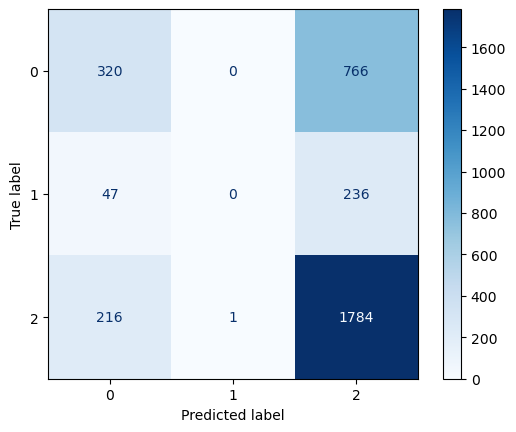


AdaBoost
Accuracy: 0.6145
F1 Score (macro): 0.3951


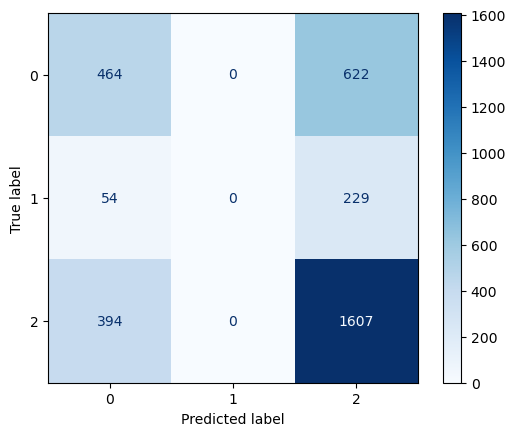


Support Vector Classifier
Accuracy: 0.6484
F1 Score (macro): 0.4030


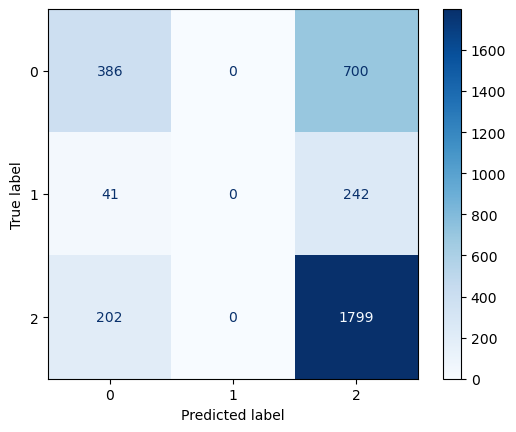

In [11]:
models = {
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Support Vector Classifier": SVC()
}

for name, model in models.items():
    print(f"\n{name}")
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', model)
                         ])
    clf.fit(X_train,y_train.values.ravel())
    preds = clf.predict(X_test)


    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")

    cm = confusion_matrix(y_test,preds)
    disp = CMD(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.show()


